# 1. Importing Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 2. Explore the data

In [4]:
df = pd.read_csv(r"C:\Users\LOQ\Desktop\IT\AI course\Algorithms\1. Linear Regression\Projects\E-Commerce\Ecommerce Customers.csv")

In [5]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [7]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


Find correlation for each feature(X) with target(y)

In [8]:
print(df[["Avg. Session Length","Time on App", "Time on Website","Length of Membership","Yearly Amount Spent"]].corr()["Yearly Amount Spent"])

Avg. Session Length     0.355088
Time on App             0.499328
Time on Website        -0.002641
Length of Membership    0.809084
Yearly Amount Spent     1.000000
Name: Yearly Amount Spent, dtype: float64


this function plot the target with each feature and find correlation also

In [9]:
import math
def plot_features_vs_target(df, target_label):
    """
    Plots scatter plots between each numerical feature in the DataFrame
    and the specified target variable, including correlation values.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing features and the target variable.

    target_label : str
        Name of the target column to be plotted on the y-axis.

    Output
    ------
    Displays scatter plots with correlation shown in the title.
    """

    # Select numerical features (exclude target)
    features = df.select_dtypes(include="number").columns.drop(target_label)

    n_features = len(features)
    cols = 2
    rows = math.ceil(n_features / cols)

    plt.figure(figsize=(10, 4 * rows))

    for i, feature in enumerate(features, start=1):
        plt.subplot(rows, cols, i)

        # Scatter plot
        plt.scatter(df[feature], df[target_label], alpha=0.5)

        # Compute correlation
        corr = df[feature].corr(df[target_label])

        # Labels and title
        plt.xlabel(feature)
        plt.ylabel(target_label)
        plt.title(f"{feature} vs {target_label}\nCorrelation = {corr:.3f}")

        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

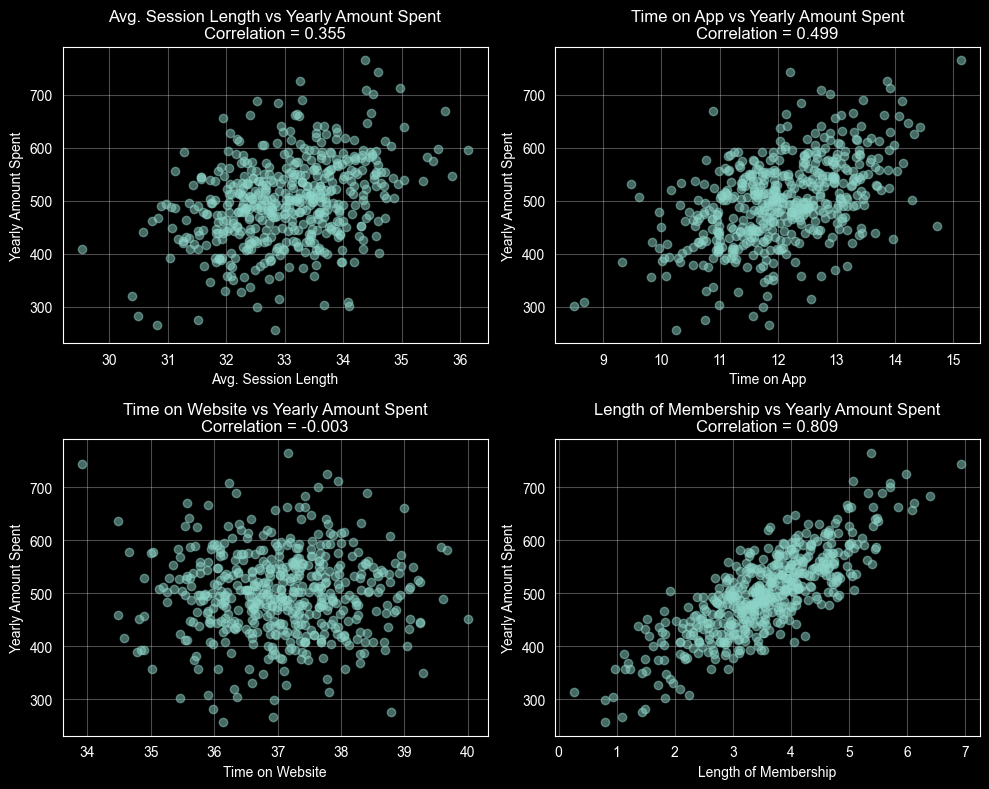

In [10]:
plot_features_vs_target(df, "Yearly Amount Spent")

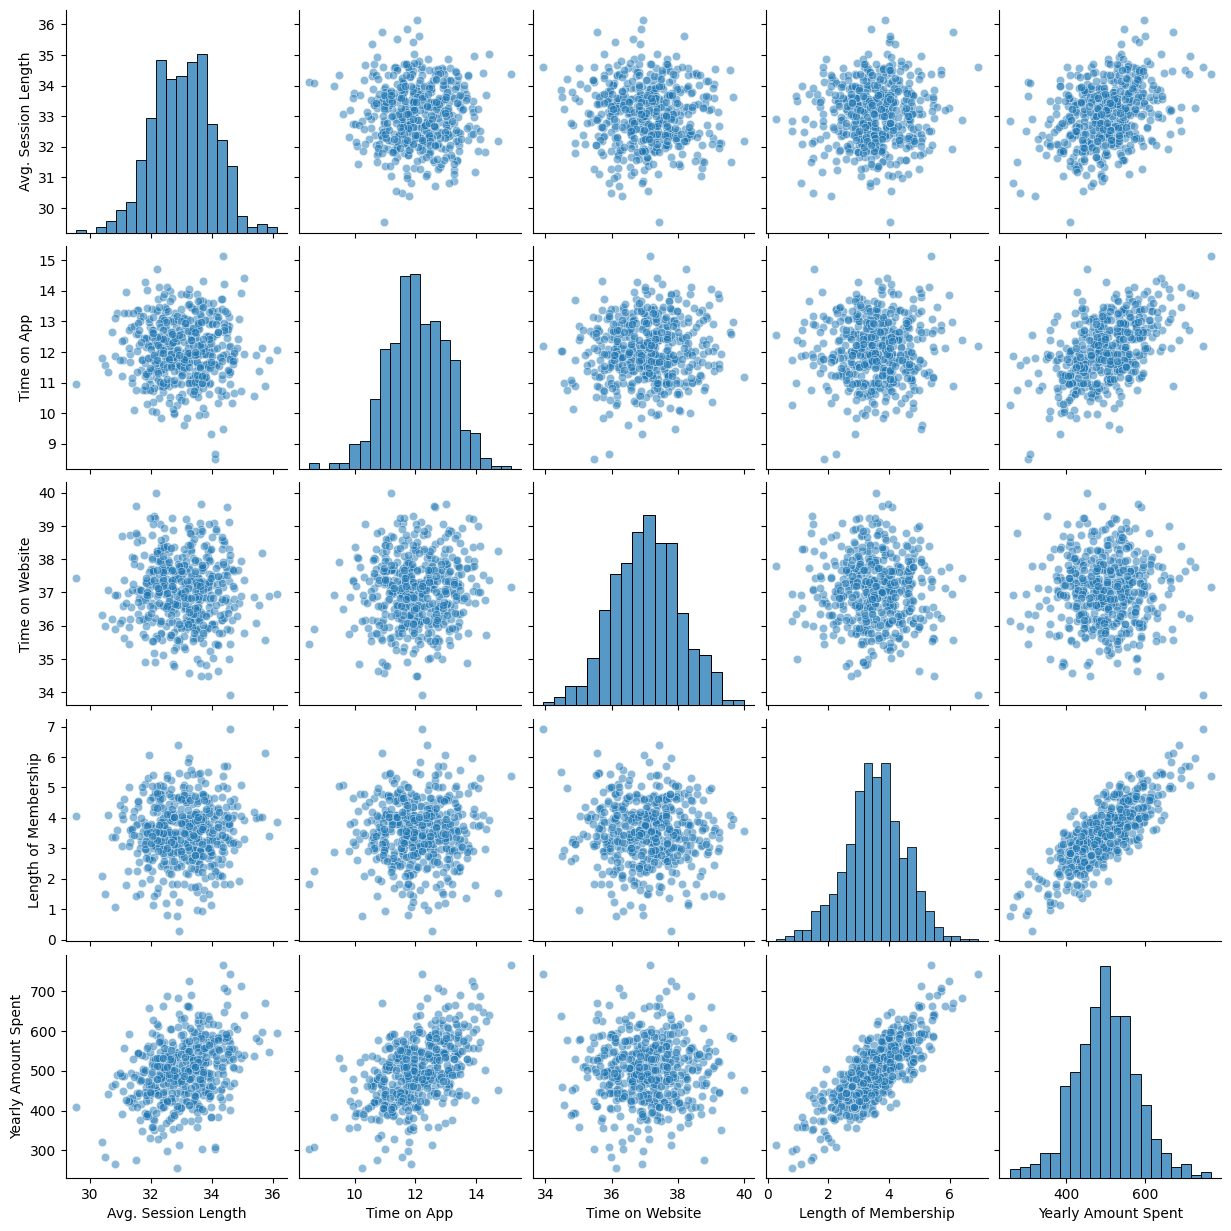

In [11]:
plt.style.use('default')
sns.pairplot(df, kind="scatter", plot_kws={"alpha": 0.5})

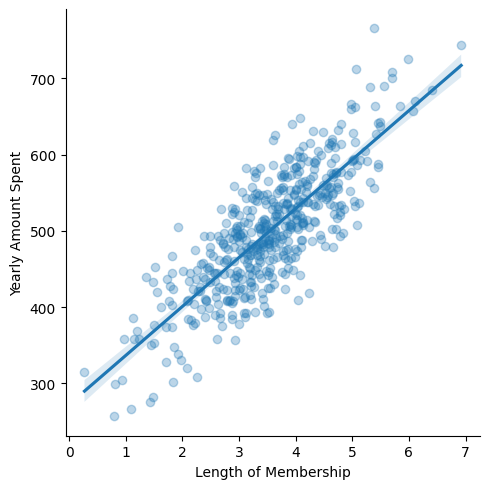

In [12]:
sns.lmplot(x='Length of Membership',
           y='Yearly Amount Spent',
           data=df,
           scatter_kws={'alpha': 0.3},)

# 3. Splitting the Data

In [13]:
X = df[["Avg. Session Length","Time on App", "Time on Website","Length of Membership"]]
y = df["Yearly Amount Spent"]
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.3, random_state=42)

# 4. Training the model

In [14]:
# f_wb = x1w1 + x2w2 + x3w3 + b

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# w1, w2, w3 ... wn
model.coef_

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [16]:
# b
model.intercept_

np.float64(-1050.6536746645725)

In [17]:
# make the predictions
y_pred = model.predict(X_test)

# 5. Evaluate the model

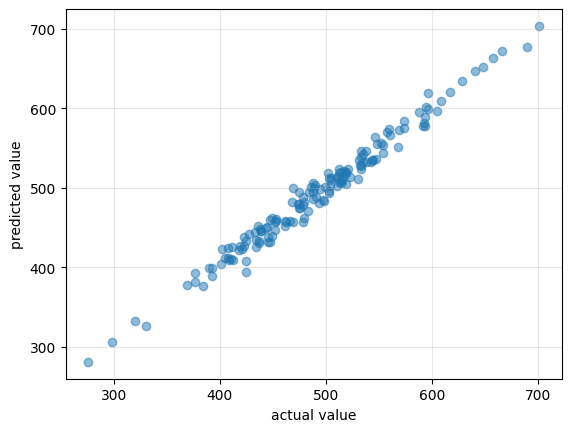

In [18]:
 plt.scatter(y_test, y_pred,alpha=0.5)
 plt.xlabel("actual value")
 plt.ylabel("predicted value")
 plt.grid(True, alpha=0.3)
 plt.show()

In [19]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
RMSE = math.sqrt(mean_squared_error(y_test, y_pred))

print("MSE:",MSE)
print("MAE:",MAE)
print("R2:",R2)
print("RMSE:",RMSE)

MSE: 103.91554136503333
MAE: 8.426091641432116
R2: 0.9808757641125855
RMSE: 10.193897260863155


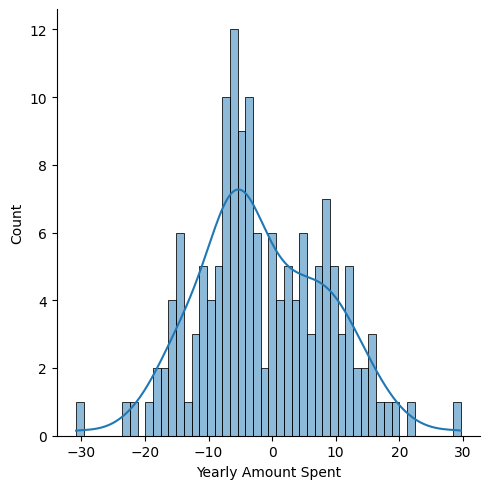

In [20]:
residuals = y_test - y_pred
sns.displot(residuals, bins=50, kde=True)

((array([-2.60376328, -2.283875  , -2.1005573 , -1.96875864, -1.86428437,
         -1.77691182, -1.70131573, -1.63435332, -1.57400778, -1.51890417,
         -1.46806125, -1.42075308, -1.37642684, -1.33465133, -1.29508341,
         -1.25744533, -1.22150891, -1.18708433, -1.15401181, -1.12215558,
         -1.0913992 , -1.06164202, -1.03279638, -1.00478546, -0.97754152,
         -0.95100448, -0.92512081, -0.89984257, -0.87512664, -0.85093408,
         -0.8272296 , -0.80398107, -0.78115919, -0.75873709, -0.73669013,
         -0.71499557, -0.69363244, -0.67258128, -0.65182406, -0.63134396,
         -0.61112532, -0.59115349, -0.57141472, -0.55189613, -0.53258558,
         -0.51347162, -0.49454346, -0.47579085, -0.45720409, -0.43877397,
         -0.4204917 , -0.40234892, -0.38433762, -0.36645016, -0.3486792 ,
         -0.33101768, -0.31345882, -0.29599609, -0.27862316, -0.26133393,
         -0.24412247, -0.22698303, -0.20991002, -0.19289797, -0.17594158,
         -0.15903562, -0.142175  , -0.

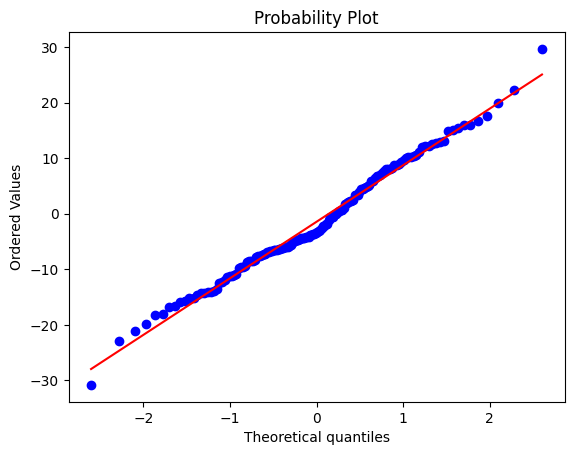

In [21]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)

In [22]:
# Example: new customer data
new_data = {
    "Avg. Session Length": [34.5],   # put your value here
    "Time on App": [12.0],            # put your value here
    "Time on Website": [39.0],        # put your value here
    "Length of Membership": [4.5]     # put your value here
}

# Convert to DataFrame
new_df = pd.DataFrame(new_data)

# Predict yearly amount spent
prediction = model.predict(new_df)

print("Predicted Yearly Amount Spent:", prediction[0])

Predicted Yearly Amount Spent: 595.4418532665513
